In [1]:
from data_utils import *
from import_pkgs import *

___

### Fig 5a: ground site performance summary

___

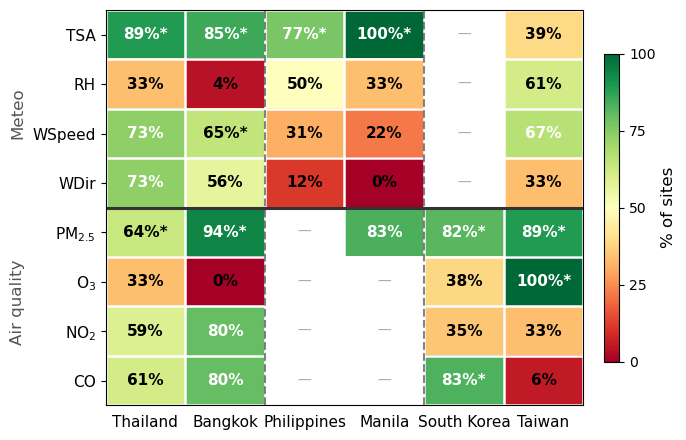

In [4]:
with open(SCORECARD_JSON) as f:
    scorecard = json.load(f)

REGIONS     = ["Thailand", "Bangkok", "Philippines", "Manila", "South Korea", "Taiwan"]
REGION_KEYS = ["Thailand", "Bangkok", "Philippines", "Manila", "SouthKorea", "Taiwan"]
VARIABLES   = ["TSA",  "RH2M", "WSpeed", "WDir", "PM2.5", "O3",          "NO2",  "CO"]
VAR_LABELS  = ["TSA",  "RH",  "WSpeed", "WDir", "PM$_{2.5}$", "O$_3$",  "NO$_2$", "CO"]

nrows = len(VARIABLES)
ncols = len(REGIONS)

imp_matrix = np.full((nrows, ncols), np.nan)
sig_matrix = np.zeros((nrows, ncols), dtype=bool)
for j, rkey in enumerate(REGION_KEYS):
    for i, var in enumerate(VARIABLES):
        val = scorecard.get(rkey, {}).get(var, {})
        if isinstance(val, dict) and val.get("degraded") is not None:
            imp_matrix[i, j] = 100 - val["degraded"]
            sig_matrix[i, j] = val.get("sig", False)
            
cmap_good = mcolors.LinearSegmentedColormap.from_list(
    "diverging_50",
    [
        (0.0,  "#d73027"), 
        (0.25, "#fc8d59"),  
        (0.5,  "#fee08b"),   
        (0.75, "#91cf60"),   
        (1.0,  "#1a9850"),   
    ]
)
fig, ax = plt.subplots(figsize=(7, 4.5))

im = ax.imshow(imp_matrix, cmap='RdYlGn', vmin=0, vmax=100, aspect="auto")

for i in range(nrows):
    for j in range(ncols):
        val = imp_matrix[i, j]
        if np.isnan(val):
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#aaaaaa")
        else:
            txt_color = "white" if val > 65 else "black"
            label = f"{val:.0f}%{'*' if sig_matrix[i, j] else ''}"
            ax.text(j, i, label, ha="center", va="center",
                    fontsize=11, fontweight="bold", color=txt_color)

for i in range(nrows + 1):
    ax.axhline(i - 0.5, color="white", linewidth=1.8)
for j in range(ncols + 1):
    ax.axvline(j - 0.5, color="white", linewidth=1.8)

ax.axhline(3.5, color="#333333", linewidth=2.2)          
ax.axvline(1.5, color="#333333", linewidth=1.5, linestyle="--", alpha=0.6) 
ax.axvline(3.5, color="#333333", linewidth=1.5, linestyle="--", alpha=0.6) 

ax.set_xticks(range(ncols))
ax.set_xticklabels(REGIONS, fontsize=11)
ax.set_yticks(range(nrows))
ax.set_yticklabels(VAR_LABELS, fontsize=11)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(bottom=False)


cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.85)
cbar.set_label("% of sites", fontsize=12)
cbar.set_ticks([0, 25, 50, 75, 100])

ax.annotate("Meteo",       xy=(-0.2, 0.74), xycoords="axes fraction",
            fontsize=12, color="#555555", rotation=90, va="center")
ax.annotate("Air quality", xy=(-0.2, 0.26), xycoords="axes fraction",
            fontsize=12, color="#555555", rotation=90, va="center")

plt.tight_layout()

plt.show()

___

### Fig 5b: DC8 flight performance summary

___

In [5]:
dr_mat=np.load(DATA_PATH+'DC8_val_performance_dr_mat.npy')
drmse_mat=np.load(DATA_PATH+'DC8_val_performance_drmse_mat.npy')
dbias_mat=np.load(DATA_PATH+'DC8_val_performance_dbias_mat.npy')
bias_ctrl_mat=np.load(DATA_PATH+'DC8_val_performance_bias_ctrl_mat.npy')
bias_test_mat=np.load(DATA_PATH+'DC8_val_performance_bias_test_mat.npy')
r_sig_mat=np.load(DATA_PATH+'DC8_val_performance_r_sig_mat.npy')
rmse_sig_mat=np.load(DATA_PATH+'DC8_val_performance_rmse_sig_mat.npy')
bias_sig_mat=np.load(DATA_PATH+'DC8_val_performance_bias_sig_mat.npy')

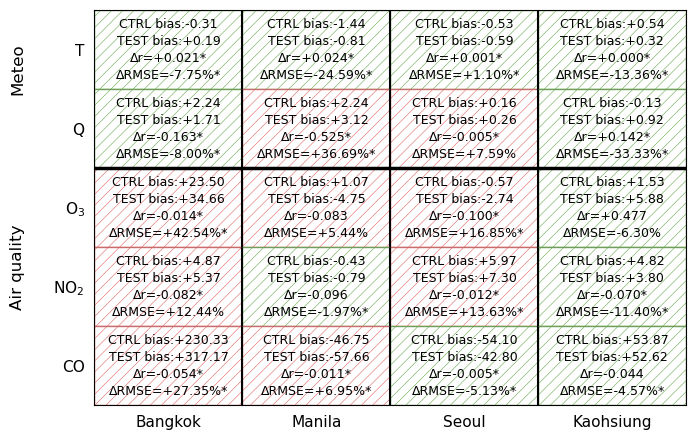

In [10]:
plt.rcParams['hatch.linewidth'] = 0.4
VARIABLES = ['T', 'Q', 'O3', 'NO2', 'CO']
METEO_VARS = ['T', 'Q']
AQ_VARS    = ['O3', 'NO2', 'CO']
VAR_LABELS = {
    'T'   : 'T',
    'Q'   : 'Q',
    'O3'  : r'O$_3$',
    'NO2' : r'NO$_2$',
    'CO'  : 'CO',
}
CITIES    = ['Bangkok', 'Manila', 'Seoul', 'Kaohsiung']
n_rows = len(VARIABLES)
n_cols = len(CITIES)

def make_improvement_heatmap():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for vi in range(n_rows):
        for ci in range(n_cols):
            dr   = dr_mat[vi, ci]
            drmse = drmse_mat[vi, ci]
            if not (np.isfinite(dr) and np.isfinite(drmse)):
                facecolor, hatch, edgecolor = 'white', '', 'none'
            elif dr > 0 or drmse < 0:
                facecolor, hatch, edgecolor = 'white', '///', '#6aa84f'
            else:
                facecolor, hatch, edgecolor = 'white', '///', '#e06666'
            ax.add_patch(plt.Rectangle(
                (ci - 0.5, vi - 0.5), 1, 1,
                facecolor=facecolor, hatch=hatch, edgecolor=edgecolor, zorder=0))

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()

    for vi in range(n_rows):
        for ci in range(n_cols):
            dr   = dr_mat[vi, ci]
            drmse = drmse_mat[vi, ci]
            c_bias = bias_ctrl_mat[vi, ci]   # ← 
            t_bias = bias_test_mat[vi, ci]   # ←
            if not (np.isfinite(dr) and np.isfinite(drmse)):
                ax.text(ci, vi, '–', ha='center', va='center',
                        fontsize=9, color='gray')
                continue

            bias_str  = f'CTRL bias:{c_bias:+.2f}\nTEST bias:{t_bias:+.2f}'
            dr_str   = f'Δr={dr:+.3f}'    + ('*' if r_sig_mat[vi, ci]   else '')
            drmse_str = f'ΔRMSE={drmse:+.2f}%' + ('*' if rmse_sig_mat[vi, ci] else '')
            label     = f'{bias_str}\n{dr_str}\n{drmse_str}'       

            ax.text(ci, vi, label, ha='center', va='center',
                    fontsize=9, color='black', linespacing=1.4)

    for ci_sep in range(1, n_cols):
        ax.axvline(ci_sep - 0.5, color='black', linewidth=1.5)
    for vi_sep in range(1, n_rows):
        ax.axhline(vi_sep - 0.5, color='gray', linewidth=0.5, linestyle=':')

    ax.axhline(len(METEO_VARS) - 0.5, color='black', linewidth=2.5)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([VAR_LABELS[v] for v in VARIABLES], fontsize=11)
    ax.tick_params(left=False, bottom=False)

    for frac, lbl in [(0.85, 'Meteo'), (0.35, 'Air quality')]:
        ax.annotate(lbl, xy=(-0.13, frac), xycoords='axes fraction',
                    ha='center', va='center', fontsize=12, rotation=90)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(CITIES, fontsize=11)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(bottom=False)

    fig.tight_layout()
    plt.show()

make_improvement_heatmap()

___

### Fig 5c: LaRC G-III flight performance summary

___

In [2]:
def plot_gcas_summary_heatmap(city_matchups, figsize=(7, 4.5)):
    rows = ["RMSE", "|Bias|", "r"]
    cols = list(city_matchups.keys())
    heatmap = pd.DataFrame(index=rows, columns=cols, dtype=float)

    for city, data in city_matchups.items():
        ctrl_daily = daily_metrics(data["ctrl"])
        test_daily = daily_metrics(data["test"])

        heatmap.loc["RMSE", city] = pct_test_better(ctrl_daily, test_daily, "rmse")
        heatmap.loc["|Bias|", city] = pct_test_better(ctrl_daily, test_daily, "abs_bias")
        heatmap.loc["r", city] = pct_test_better(ctrl_daily, test_daily, "r")

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, fontsize=12)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(rows, fontsize=12)

    for i in range(len(rows)):
        for j in range(len(cols)):
            val = heatmap.iloc[i, j]
            if np.isfinite(val):
                color = "white" if (val >= 65 or val <= 20) else "black"
                ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                        fontsize=13, fontweight="bold", color=color)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=13, color="gray")

    for x in np.arange(-0.5, len(cols), 1):
        ax.axvline(x, color="white", lw=2)
    for y in np.arange(-0.5, len(rows), 1):
        ax.axhline(y, color="white", lw=2)

    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04, shrink=0.8)
    cbar.set_label("% of flight days", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    fig.tight_layout()
    return fig, ax, heatmap

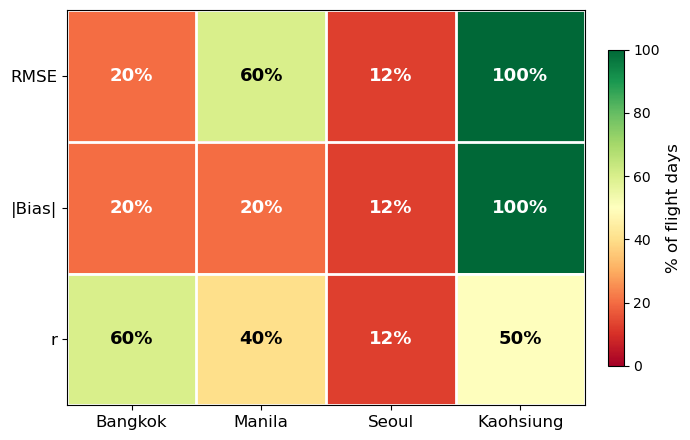

In [3]:
city_matchups = {
    "Bangkok": {
        "ctrl": ctrl_bangkok_matchups,
        "test": test_bangkok_matchups,
    },
    "Manila": {
        "ctrl": ctrl_manila_matchups,
        "test": test_manila_matchups,
    },
    "Seoul": {
        "ctrl": ctrl_seoul_matchups,
        "test": test_seoul_matchups,
    },
    "Kaohsiung": {
        "ctrl": ctrl_kaohsiung_matchups,
        "test": test_kaohsiung_matchups,
    },
    
}

fig, ax, heatmap = plot_gcas_summary_heatmap(city_matchups, figsize=(7,4.5))